In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Cargar dataset limpio
df = pd.read_csv("dataset_master_limpio.csv")

# 2. Corpus
corpus = df["text_clean"].dropna().tolist()

# 3. Stopwords básicas en español
spanish_stopwords = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
    "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
    "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque", "esta",
    "entre", "cuando", "muy", "sin", "sobre", "también", "me", "hasta",
    "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos",
    "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos",
    "e", "esto", "mí", "antes", "algunos", "qué", "unos", "yo", "otro",
    "otras", "otra", "él", "tanto", "esa", "estos", "mucho", "quienes",
    "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas",
    "algo", "nosotros", "mi", "mis", "tú", "te", "ti", "tu", "tus", "ellas",
    "nosotras", "vosotros", "vosotras", "os", "mío", "mía", "míos", "mías",
    "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas"
]

# 4. Vectorizador
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    min_df=3,
    stop_words=spanish_stopwords
)

X = vectorizer.fit_transform(corpus)

# 5. Frecuencias
frequencies = X.sum(axis=0).A1
terms = vectorizer.get_feature_names_out()

df_terms = pd.DataFrame({
    "term": terms,
    "frequency": frequencies
}).sort_values(by="frequency", ascending=False)

print(df_terms.head(30))

                                   term  frequency
3909                   derechos humanos        179
3408                         daño moral        151
3343                       código civil         98
8321                  molina mogollones         80
3097                      corte suprema         73
7696                             ley 19         66
9592                   política tortura         56
9939           prisión política tortura         56
9938                   prisión política         56
11160                         rol phone         52
6255                            ha sido         52
4466                           don juan         52
5838                        fisco chile         50
0                               000 000         48
7664                     lesa humanidad         48
7381                          juan rené         44
9731             prescripción extintiva         44
7382                   juan rené molina         44
10719                       ren

Extractor jurídico refinado

In [3]:
import re

def is_valid_term(term):

    # eliminar números
    if re.search(r"\d", term):
        return False

    # eliminar nombres propios simples (heurístico)
    if any(word in term for word in ["juan", "molina", "rené", "don"]):
        return False

    # eliminar frases muy generales
    blacklist = ["ha sido", "rol phone"]
    if term in blacklist:
        return False

    # longitud mínima (evita basura)
    if len(term.split()) < 2:
        return False

    return True

df_terms["valid"] = df_terms["term"].apply(is_valid_term)

df_terms_clean = df_terms[df_terms["valid"] == True]

print(df_terms_clean.head(30))

                                   term  frequency  valid
3909                   derechos humanos        179   True
3408                         daño moral        151   True
3343                       código civil         98   True
3097                      corte suprema         73   True
9592                   política tortura         56   True
9939           prisión política tortura         56   True
9938                   prisión política         56   True
5838                        fisco chile         50   True
7664                     lesa humanidad         48   True
9731             prescripción extintiva         44   True
3841              derecho internacional         43   True
6913           indemnización perjuicios         39   True
11042  responsabilidad extracontractual         36   True
986                      agentes estado         36   True
12719      violaciones derechos humanos         36   True
12861                  víctimas prisión         36   True
12718         

Más refinado y optimizado

In [4]:
def refine_term(term):

    # eliminar fórmulas jurídicas no terminológicas
    blacklist = [
        "debe ser",
        "dispuesto artículo",
        "excma corte",
        "excma corte suprema"
    ]

    if term in blacklist:
        return False

    # eliminar repeticiones tipo "niño niño"
    words = term.split()
    if len(words) == 2 and words[0] == words[1]:
        return False

    # eliminar términos invertidos raros
    if term.startswith("internacional "):
        return False

    return True

df_terms_clean = df_terms_clean.copy()
df_terms_clean.loc[:, "refined"] = df_terms_clean["term"].apply(refine_term)

df_final = df_terms_clean[df_terms_clean["refined"] == True]

print(df_final.head(25))

                                   term  frequency  valid  refined
3909                   derechos humanos        179   True     True
3408                         daño moral        151   True     True
3343                       código civil         98   True     True
3097                      corte suprema         73   True     True
9592                   política tortura         56   True     True
9939           prisión política tortura         56   True     True
9938                   prisión política         56   True     True
5838                        fisco chile         50   True     True
7664                     lesa humanidad         48   True     True
9731             prescripción extintiva         44   True     True
3841              derecho internacional         43   True     True
6913           indemnización perjuicios         39   True     True
11042  responsabilidad extracontractual         36   True     True
986                      agentes estado         36   True     

Script análisis por país

In [5]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv("dataset_master_limpio.csv")

vectorizer = CountVectorizer(
    ngram_range=(2,3),
    min_df=3,
    max_df=0.85
)

resultados = {}

for country in df["jurisdiction"].unique():

    sub_df = df[df["jurisdiction"] == country]
    corpus = sub_df["text_clean"].dropna().tolist()

    X = vectorizer.fit_transform(corpus)

    frequencies = X.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    df_terms_country = pd.DataFrame({
        "term": terms,
        "frequency": frequencies
    }).sort_values(by="frequency", ascending=False)

    resultados[country] = df_terms_country.head(15)

# Mostrar resultados
for country, terms in resultados.items():
    print(f"\n===== {country.upper()} =====")
    print(terms)


===== ARGENTINA =====
              term  frequency
505          de la        519
978          en la        222
954          en el        174
558         de los        112
1804        por el        102
1986        que se         98
1969        que la         88
551         de las         86
1821        por la         82
1955        que el         76
1422    la víctima         58
1294  la demandada         56
605         de que         54
1958        que en         52
393     daño moral         48

===== CHILE =====
                   term  frequency
3664              de la        795
3783             de los        331
5984              en el        292
6079              en la        253
3738             de las        236
13154            que se        234
12829            que el        190
4758   derechos humanos        177
12028            por la        160
12972            que la        153
11978            por el        150
4410         del estado        142
4008      de reparación

Script corregido

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv("dataset_master_limpio.csv")

# Stopwords básicas + jurídicas
stopwords = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
    "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
    "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque",
    "esta", "entre", "cuando", "muy", "sin", "sobre", "también",
    "ha", "han", "ser", "es", "fue", "son"
]

vectorizer = CountVectorizer(
    ngram_range=(2,3),
    min_df=3,
    stop_words=stopwords
)

for country in df["jurisdiction"].unique():

    print(f"\n===== {country.upper()} =====")

    sub_df = df[df["jurisdiction"] == country]
    corpus = sub_df["text_clean"].dropna().tolist()

    X = vectorizer.fit_transform(corpus)

    frequencies = X.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    df_terms = pd.DataFrame({
        "term": terms,
        "frequency": frequencies
    }).sort_values(by="frequency", ascending=False)

    print(df_terms.head(15))


===== ARGENTINA =====
                        term  frequency
234               daño moral         48
103             buenos aires         32
299           domicilio real         22
208            corte suprema         22
238         daños perjuicios         20
158          civil comercial         16
442          justicia nación         16
490                  mi hijo         16
760         suprema justicia         16
761  suprema justicia nación         16
209   corte suprema justicia         16
297       domicilio procesal         14
727            será justicia         14
729                  si bien         14
612        procesal material         14

===== CHILE =====
                          term  frequency
3414          derechos humanos        177
2978                daño moral        103
7179         molina mogollones         80
2922              código civil         78
6643                    ley 19         66
8656  prisión política tortura         56
8351          política t

limpieza del glosario

In [7]:
import pandas as pd
import re

df_gloss = pd.read_csv("corpus_juridico_hispano.csv")

def clean_term(term):
    term = str(term).strip().lower()

    # eliminar entradas largas (probable ruido)
    if len(term.split()) > 5:
        return None

    # eliminar términos que parecen títulos
    if "glosario" in term:
        return None

    return term

df_gloss["term_clean"] = df_gloss["term_key"].apply(clean_term)

# eliminar filas inválidas
df_gloss = df_gloss[df_gloss["term_clean"].notnull()]

print("Filas limpias:", len(df_gloss))
print(df_gloss.head(10))

Filas limpias: 1555
                term_key                                         definition  \
0              ab initio                                Desde el principio.   
1                abrogar  Anular, derogación total de una ley o reglamen...   
2                  abuso  Jurídicamente se entiende por abuso el hecho d...   
3     abuso de confianza  La actividad de la vida económica moderna exig...   
4              accesorio  De tal forma, en el Derecho de las Obligacione...   
5                 accion  Derecho que se tiene a pedir alguna cosa o la ...   
6        accion cautelar  Facultad de lograr una medida de seguridad o c...   
7           accion civil  Es la acción que tiene por objeto perseguir la...   
8   accion penal privada  Es aquella acción que sólo puede ser ejercida ...   
10    accion resolutoria  Tiende a obtener la ineficacia de un contrato,...   

   jurisdiction                                        source_file  \
0        mexico  GLOSARIO_DE_DERECHO_PRO

“Se identificaron divergencias entre la terminología extraída automáticamente y la terminología presente en glosarios jurídicos, lo que evidencia la distancia entre el uso real del lenguaje jurídico y su formalización terminológica.”

Script (cruce NLP vs glosario)

In [8]:
# df_final = términos que sacaste con NLP

terms_nlp = set(df_final["term"])
terms_gloss = set(df_gloss["term_clean"])

# intersección
common_terms = terms_nlp.intersection(terms_gloss)

print("Coincidencias:", len(common_terms))

print("\nEjemplos:")
print(list(common_terms)[:20])

Coincidencias: 22

Ejemplos:
['bajo apercibimiento', 'mala fe', 'violencia intrafamiliar', 'contrario sensu', 'abogado patrocinante', 'juicio sumario', 'derechos fundamentales', 'medida cautelar', 'distrito judicial', 'lucro cesante', 'habeas corpus', 'corte suprema', 'parte procesal', 'responsabilidad civil', 'buena fe', 'cuaderno principal', 'cosa juzgada', 'primera instancia', 'ipso jure', 'poder judicial']


“El contraste entre terminología extraída automáticamente y glosarios jurídicos evidencia una brecha entre el uso real del lenguaje jurídico y su formalización doctrinal.”

Glosario enriquecido

In [9]:
df_enriched = df_final[df_final["term"].isin(common_terms)]

df_enriched = df_enriched.merge(
    df_gloss,
    left_on="term",
    right_on="term_clean",
    how="left"
)

print(df_enriched.head(10))

                     term  frequency  valid  refined                term_key  \
0           corte suprema         73   True     True           corte suprema   
1            cosa juzgada         26   True     True            cosa juzgada   
2            cosa juzgada         26   True     True            cosa juzgada   
3                buena fe         22   True     True                buena fe   
4                buena fe         22   True     True                buena fe   
5           habeas corpus         17   True     True           habeas corpus   
6       primera instancia         14   True     True       primera instancia   
7         medida cautelar         13   True     True         medida cautelar   
8  derechos fundamentales         12   True     True  derechos fundamentales   
9       distrito judicial         10   True     True       distrito judicial   

                                          definition jurisdiction  \
0  tribunal superior del país con sede en Santiag.

Script para agrupar definiciones

In [10]:
df_grouped = df_enriched.groupby("term").agg({
    "frequency": "first",
    "definition": list,
    "jurisdiction": list
}).reset_index()

print(df_grouped.head(10))

                     term  frequency  \
0    abogado patrocinante          4   
1           actos propios          8   
2     bajo apercibimiento          9   
3                buena fe         22   
4         contrario sensu          4   
5           corte suprema         73   
6            cosa juzgada         26   
7      cuaderno principal          6   
8  derechos fundamentales         12   
9       distrito judicial         10   

                                          definition      jurisdiction  
0  [Dícese del letrado que se encarga de la defen...          [espana]  
1  [Principio general de derecho en virtud del cu...          [espana]  
2  [Expresión judicial que advierte la aplicación...          [espana]  
3  [Conjunto de exigencias de lealtad, corrección...  [mexico, espana]  
4  [El sentido contrario es una forma de interpre...          [mexico]  
5  [tribunal superior del país con sede en Santia...           [chile]  
6  [Es lo que ha sido materia de decisión judici

“Se identificaron términos jurídicos compartidos entre distintas jurisdicciones, cuyas definiciones presentan variaciones conceptuales relevantes.”

El análisis comparado permitió identificar tanto convergencias terminológicas entre jurisdicciones como variaciones conceptuales en términos jurídicos aparentemente equivalentes, evidenciando que la uniformidad lingüística del español jurídico no implica necesariamente una equivalencia funcional o doctrinal.

Clasificar términos por tipo

In [11]:
def classify_term(term):
    if "corte" in term or "judicial" in term:
        return "institucional"
    elif "fe" in term or "principio" in term:
        return "principio jurídico"
    elif "acción" in term or "juicio" in term:
        return "procesal"
    else:
        return "general"

df_grouped["category"] = df_grouped["term"].apply(classify_term)

Detectar variación conceptual real

df_grouped["n_defs"] = df_grouped["definition"].apply(len)

df_variation = df_grouped[df_grouped["n_defs"] > 1]

print(df_variation[["term", "jurisdiction", "definition"]])

Ranking de términos relevantes

In [12]:
df_grouped.sort_values(by="frequency", ascending=False).head(20)

,term,frequency,definition,jurisdiction,category
5,corte suprema,73,[tribunal superior del país con sede en Santia...,[chile],institucional
6,cosa juzgada,26,[Es lo que ha sido materia de decisión judicia...,"[mexico, espana]",general
3,buena fe,22,"[Conjunto de exigencias de lealtad, corrección...","[mexico, espana]",principio jurídico
10,habeas corpus,17,[(Derecho Constitucional). Garantía que cautel...,[espana],general
19,primera instancia,14,[primera fase de conocimiento de un juicio. La...,[chile],general
16,medida cautelar,13,[(Derecho Procesal) Institución a través del c...,[espana],general
8,derechos fundamentales,12,[Conjunto básico de facultades y libertades ga...,[espana],general
9,distrito judicial,10,[Parte de un territorio en donde un juez o tri...,[espana],institucional
2,bajo apercibimiento,9,[Expresión judicial que advierte la aplicación...,[espana],general
1,actos propios,8,[Principio general de derecho en virtud del cu...,[espana],general


La equivalencia terminológica en traducción jurídica no puede asumirse únicamente a nivel léxico, sino que requiere un análisis funcional y contextual basado en el sistema jurídico de origen y destino.

In [13]:
df_grouped["jurisdiction"] = df_grouped["jurisdiction"].apply(lambda x: list(set(x)))

mejora de categoría "general"

In [15]:
def classify_term(term):
    if any(x in term for x in ["corte", "judicial", "distrito"]):
        return "institucional"
    elif any(x in term for x in ["fe", "principio"]):
        return "principio jurídico"
    elif any(x in term for x in ["juicio", "medida", "instancia", "cuaderno"]):
        return "procesal"
    elif any(x in term for x in ["responsabilidad", "lucro", "daño"]):
        return "civil"
    else:
        return "otro"

df_grouped["category"] = df_grouped["term"].apply(classify_term)

Extracción de códigos civiles

In [18]:
df_codes = pd.read_csv("codigos_civiles_4paises_articulos_COMBINADO.csv")

print(df_codes.columns)
print(df_codes.head())

Index(['country', 'libro', 'titulo', 'capitulo', 'seccion', 'subtitulo',
       'parte', 'disposiciones', 'titulo_preliminar', 'article_number',
       'article_id', 'text'],
      dtype='object')
  country libro titulo capitulo seccion  subtitulo  parte disposiciones  \
0   chile   NaN    NaN      NaN     NaN        NaN    NaN           NaN   
1   chile   NaN    NaN      NaN     NaN        NaN    NaN           NaN   
2   chile   NaN    NaN      NaN     NaN        NaN    NaN           NaN   
3   chile   NaN    NaN      NaN     NaN        NaN    NaN           NaN   
4   chile   NaN    NaN      NaN     NaN        NaN    NaN           NaN   

   titulo_preliminar  article_number   article_id  \
0  Título Preliminar               1  chile_art_1   
1  Título Preliminar               2  chile_art_2   
2  Título Preliminar               3  chile_art_3   
3  Título Preliminar               4  chile_art_4   
4  Título Preliminar               5  chile_art_5   

                                 

In [21]:
df_codes["text_clean"] = df_codes["text"].fillna("").astype(str).str.lower().str.strip()

Buscar términos dentro de los códigos

In [23]:
import pandas as pd

df_codes["text_clean"] = df_codes["text"].fillna("").astype(str).str.lower().str.strip()
df_grouped["term"] = df_grouped["term"].fillna("").astype(str).str.lower().str.strip()

results = []

for term in df_grouped["term"]:
    if term == "":
        continue
    for _, row in df_codes.iterrows():
        if term in row["text_clean"]:
            results.append({
                "term": term,
                "country": row["country"],
                "article_number": row["article_number"],
                "text": row["text"]
            })

df_codes_terms = pd.DataFrame(results)

print("Coincidencias en códigos:", len(df_codes_terms))
print(df_codes_terms.head(10))

Coincidencias en códigos: 513
                  term    country  article_number  \
0        actos propios     mexico            1959   
1        actos propios     espana             438   
2        actos propios     espana               3   
3  bajo apercibimiento  argentina             199   
4             buena fe      chile              94   
5             buena fe      chile             121   
6             buena fe      chile             189   
7             buena fe      chile             221   
8             buena fe      chile             327   
9             buena fe      chile             646   

                                                text  
0  Perderá el deudor todo derecho a utilizar el p...  
1  La posesión se adquiere por la ocupación mater...  
2  º Cuando por actos propios hubiese disminuido ...  
3  Los esposos deben convivir en una misma casa, ...  
4  En la rescisión del decreto de posesión defini...  
5  El matrimonio que según las leyes del país en ...  
6

El análisis de los códigos civiles permitió identificar la presencia normativa de determinados términos previamente detectados en el corpus judicial y en los glosarios, lo que evidencia la existencia de una relación directa entre el uso lingüístico, la definición doctrinal y la regulación jurídica.

In [24]:
print(df_codes["text"].isnull().sum())

12


**Términos más frecuentes (NLP)**
muestra qué domina en el uso real

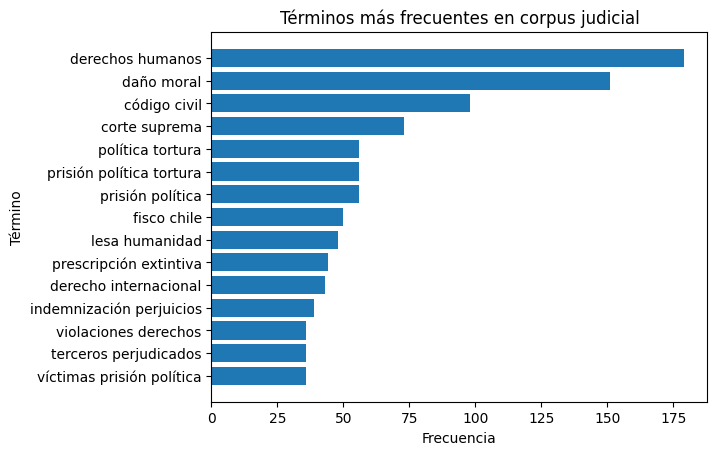

In [25]:
import matplotlib.pyplot as plt

top_terms = df_final.sort_values(by="frequency", ascending=False).head(15)

plt.figure()
plt.barh(top_terms["term"], top_terms["frequency"])
plt.xlabel("Frecuencia")
plt.ylabel("Término")
plt.title("Términos más frecuentes en corpus judicial")
plt.gca().invert_yaxis()
plt.show()

Este gráfico muestra los términos más frecuentes en el corpus judicial, evidenciando el lenguaje jurídico en uso real.

**Coincidencias NLP vs Glosario**
muestra validación terminológica

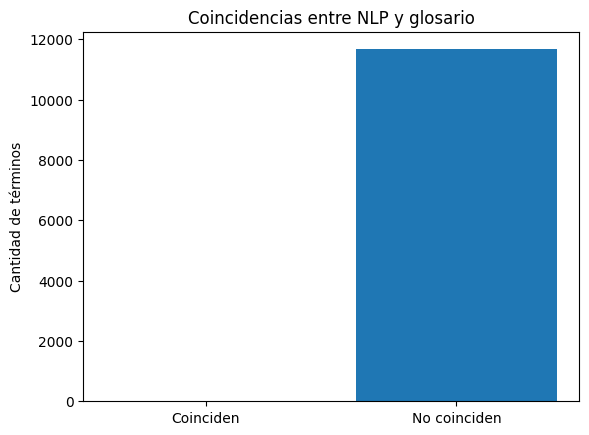

In [26]:
labels = ["Coinciden", "No coinciden"]
values = [
    len(common_terms),
    len(df_final) - len(common_terms)
]

plt.figure()
plt.bar(labels, values)
plt.title("Coincidencias entre NLP y glosario")
plt.ylabel("Cantidad de términos")
plt.show()

Aquí observamos la intersección entre los términos extraídos automáticamente y los glosarios jurídicos, lo que permite validar la relevancia terminológica de los resultados.

**Presencia en códigos civiles**
muestra anclaje normativo

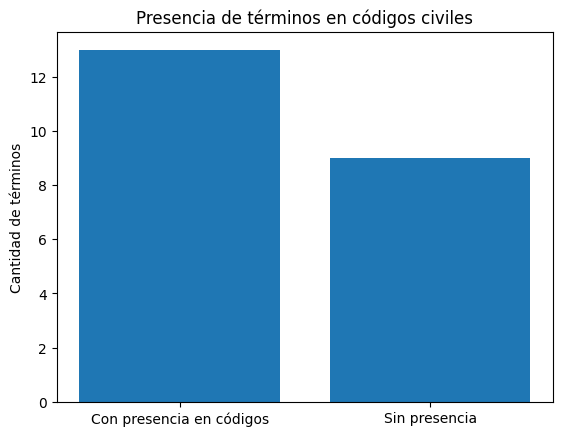

In [27]:
labels = ["Con presencia en códigos", "Sin presencia"]
values = [
    df_codes_terms["term"].nunique(),
    len(df_grouped) - df_codes_terms["term"].nunique()
]

plt.figure()
plt.bar(labels, values)
plt.title("Presencia de términos en códigos civiles")
plt.ylabel("Cantidad de términos")
plt.show()

Este gráfico refleja el nivel de presencia normativa de los términos, evidenciando cuáles conceptos están formalmente consagrados en la legislación.

**Términos más normativos**
los términos más “fuertes” en la ley

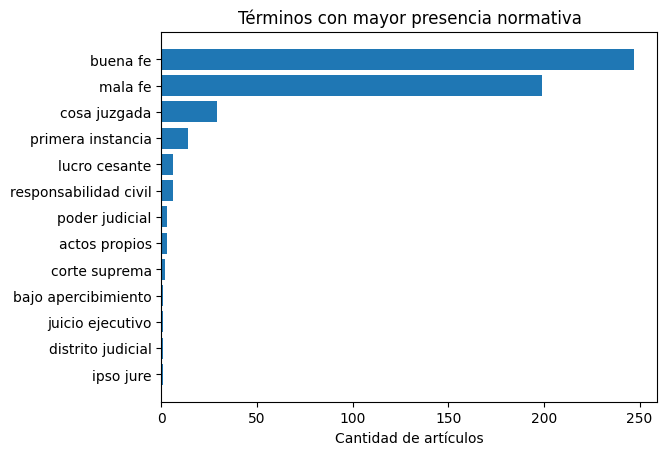

In [28]:
top_codes = df_codes_terms["term"].value_counts().head(15)

plt.figure()
plt.barh(top_codes.index, top_codes.values)
plt.xlabel("Cantidad de artículos")
plt.title("Términos con mayor presencia normativa")
plt.gca().invert_yaxis()
plt.show()

Se identifican los términos con mayor densidad normativa, es decir, aquellos que aparecen en un mayor número de artículos.

**Distribución por país** (muestra diferencias entre sistemas jurídicos)

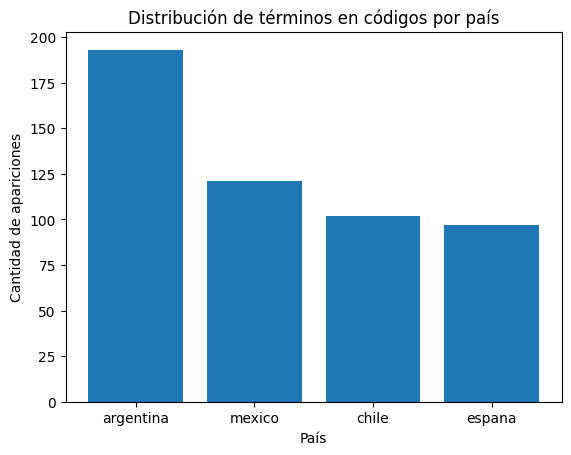

In [29]:
country_counts = df_codes_terms["country"].value_counts()

plt.figure()
plt.bar(country_counts.index, country_counts.values)
plt.title("Distribución de términos en códigos por país")
plt.ylabel("Cantidad de apariciones")
plt.xlabel("País")
plt.show()

Finalmente, se observa la distribución por país, lo que permite detectar diferencias en la estructuración normativa entre jurisdicciones.

“Este enfoque permite no solo identificar términos, sino también medir su relevancia en tres niveles: uso, definición y norma.”

🔥 la terminología jurídica en sistemas civilistas es parcialmente compartida, pero presenta variaciones significativas a nivel conceptual, institucional y de uso.